In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True)
print(f"Backend selected: {backend.name} | {backend.num_qubits} qubits")

Backend selected: ibm_marrakesh | 156 qubits


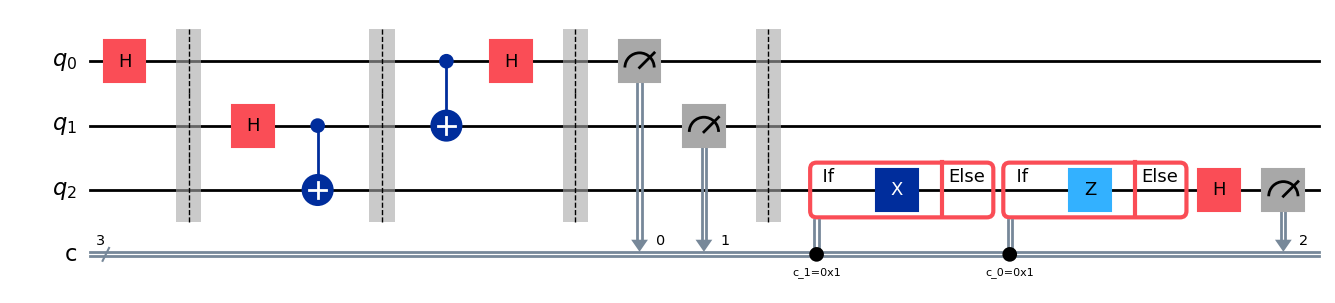

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator

q = QuantumRegister(3, 'q')
c = ClassicalRegister(3, 'c')
qc = QuantumCircuit(q, c)

# Step 1: Prepare MESSAGE state |+⟩ on q[0]
qc.h(q[0])
qc.barrier()

# Step 2: Create Bell pair between Alice (q[1]) and Bob (q[2])
qc.h(q[1])
qc.cx(q[1], q[2])
qc.barrier()

# Step 3: Bell measurement on Alice's side
qc.cx(q[0], q[1])
qc.h(q[0])
qc.barrier()

# Step 4: Alice measures
qc.measure(q[0], c[0])
qc.measure(q[1], c[1])
qc.barrier()

# Step 5: Bob applies conditional corrections
true_body_x = QuantumCircuit(1, 0)
true_body_x.x(0)
false_body_x = QuantumCircuit(1, 0)  # empty but same shape

true_body_z = QuantumCircuit(1, 0)
true_body_z.z(0)
false_body_z = QuantumCircuit(1, 0)  # empty but same shape

qc.if_else((c[1], 1), true_body_x, false_body_x, [q[2]], [])
qc.if_else((c[0], 1), true_body_z, false_body_z, [q[2]], [])

# Step 6: Verify in X basis
qc.h(q[2])
qc.measure(q[2], c[2])
qc.draw("mpl")

In [5]:
qc_ideal = QuantumCircuit(3)
qc_ideal.h(0)
qc_ideal.h(1)
qc_ideal.cx(1, 2)
qc_ideal.cx(0, 1)
qc_ideal.h(0)

sv = Statevector(qc_ideal)
print("Ideal statevector (pre-measurement):")
print(sv.draw('latex_source'))

Ideal statevector (pre-measurement):
\frac{\sqrt{2}}{4} |000\rangle+\frac{\sqrt{2}}{4} |001\rangle+\frac{\sqrt{2}}{4} |010\rangle- \frac{\sqrt{2}}{4} |011\rangle+\frac{\sqrt{2}}{4} |100\rangle- \frac{\sqrt{2}}{4} |101\rangle+\frac{\sqrt{2}}{4} |110\rangle+\frac{\sqrt{2}}{4} |111\rangle


In [6]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Transpile — optimization_level=1 is safer for dynamic circuits
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)

# Submit with Sampler instead of Estimator
sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1024)

print(f"Job submitted. ID: {job.job_id()}")
print("Waiting for IBM Quantum hardware...")

result = job.result()
counts = result[0].data.c.get_counts()
print(f"\nRaw counts: {counts}")

# Fidelity: Bob's qubit is c[2] (leftmost bit in Qiskit's notation)
# After H rotation, |+⟩ → |0⟩, so success = c[2] is '0'
success = sum(v for k, v in counts.items() if k[0] == '0')
total = sum(counts.values())
fidelity = success / total

print(f"\nTeleportation fidelity : {fidelity:.4f}")
print(f"Theoretical ideal      : 1.0000")
print(f"Your Bell state ref    : 0.9894")

Job submitted. ID: d8jntsjqv2lc7384b5n0
Waiting for IBM Quantum hardware...

Raw counts: {'000': 249, '011': 232, '001': 263, '010': 251, '100': 6, '101': 7, '111': 8, '110': 8}

Teleportation fidelity : 0.9717
Theoretical ideal      : 1.0000
Your Bell state ref    : 0.9894
